# Librerias requeridas

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from pathlib import Path
import shutil
import kagglehub


# Descarga del dataset

In [50]:
data_dir = Path.cwd() / "Data"
data_dir.mkdir(parents=True, exist_ok=True)

download_path = Path(
    kagglehub.dataset_download(
        "andradaolteanu/gtzan-dataset-music-genre-classification"
    )
)

# Copiar el contenido a ./Data si es necesario
if download_path.resolve() != data_dir.resolve():
    for item in download_path.iterdir():
        dst = data_dir / item.name
        if not dst.exists():
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)

path = data_dir

print("Dataset disponible en:", path)

Dataset disponible en: /home/thunderm/intro-ia/proyecto-2-intro-IA/Data


# Analisis preliminar del dataset

In [51]:
df = pd.read_csv("./Data/features_30_sec.csv")

In [52]:
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [53]:
print(df.shape)

(1000, 60)


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   str    
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             1000 non-nu

In [55]:
df.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


In [56]:
df.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df["label"].value_counts()

label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64

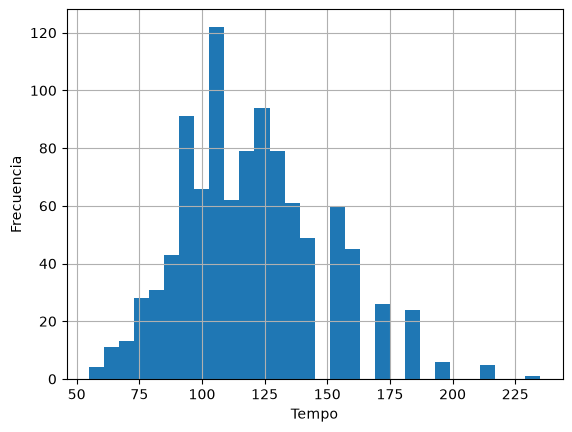

In [59]:
grafico = df["tempo"].hist(bins=30)

plt.xlabel("Tempo")
plt.ylabel("Frecuencia")
plt.show()

In [60]:
corr = df.corr(numeric_only=True)

corr

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
length,1.000000,0.017426,0.073979,0.101801,0.116661,0.052175,0.121994,0.062503,0.118993,0.040363,...,-0.019677,0.025483,0.039179,0.003457,-0.025331,0.014822,0.010576,0.045884,0.014803,0.050338
chroma_stft_mean,0.017426,1.000000,-0.461729,0.499926,0.261544,0.615728,0.285926,0.517710,0.041088,0.598122,...,0.332359,-0.452955,-0.163474,-0.456298,0.269935,-0.478452,-0.089509,-0.501768,0.281965,-0.548577
chroma_stft_var,0.073979,-0.461729,1.000000,-0.078777,0.290138,-0.246441,0.305819,-0.036896,0.346907,-0.168721,...,-0.311178,0.361752,0.205117,0.389468,-0.239597,0.378200,0.184323,0.365291,-0.231715,0.333581
rms_mean,0.101801,0.499926,-0.078777,1.000000,0.607399,0.510154,0.324077,0.530017,0.099830,0.537902,...,0.083936,-0.160347,-0.029562,-0.163490,0.118239,-0.164834,0.031297,-0.207680,0.124413,-0.252434
rms_var,0.116661,0.261544,0.290138,0.607399,1.000000,0.347831,0.583353,0.402333,0.320793,0.368570,...,-0.093893,0.091863,0.168169,0.100234,-0.002585,0.058050,0.186953,0.049879,0.029364,0.012087
spectral_centroid_mean,0.052175,0.615728,-0.246441,0.510154,0.347831,1.000000,0.520548,0.904435,0.011256,0.979637,...,0.153741,-0.180200,0.027473,-0.158666,0.228275,-0.136272,0.027918,-0.146316,0.269601,-0.205531
spectral_centroid_var,0.121994,0.285926,0.305819,0.324077,0.583353,0.520548,1.000000,0.622834,0.636494,0.545128,...,-0.186864,0.072319,0.175573,0.094155,-0.063059,0.059431,0.188945,0.046847,-0.021837,0.008115
spectral_bandwidth_mean,0.062503,0.517710,-0.036896,0.530017,0.402333,0.904435,0.622834,1.000000,0.220159,0.956189,...,0.027206,-0.146152,0.105010,-0.122739,0.114873,-0.102737,0.098217,-0.121584,0.187786,-0.193574
spectral_bandwidth_var,0.118993,0.041088,0.346907,0.099830,0.320793,0.011256,0.636494,0.220159,1.000000,0.053632,...,-0.267098,0.104727,0.128638,0.108537,-0.178183,0.074145,0.124554,0.028696,-0.157001,0.026121
rolloff_mean,0.040363,0.598122,-0.168721,0.537902,0.368570,0.979637,0.545128,0.956189,0.053632,1.000000,...,0.132443,-0.180777,0.039693,-0.157343,0.205222,-0.131517,0.048248,-0.144641,0.256570,-0.215384


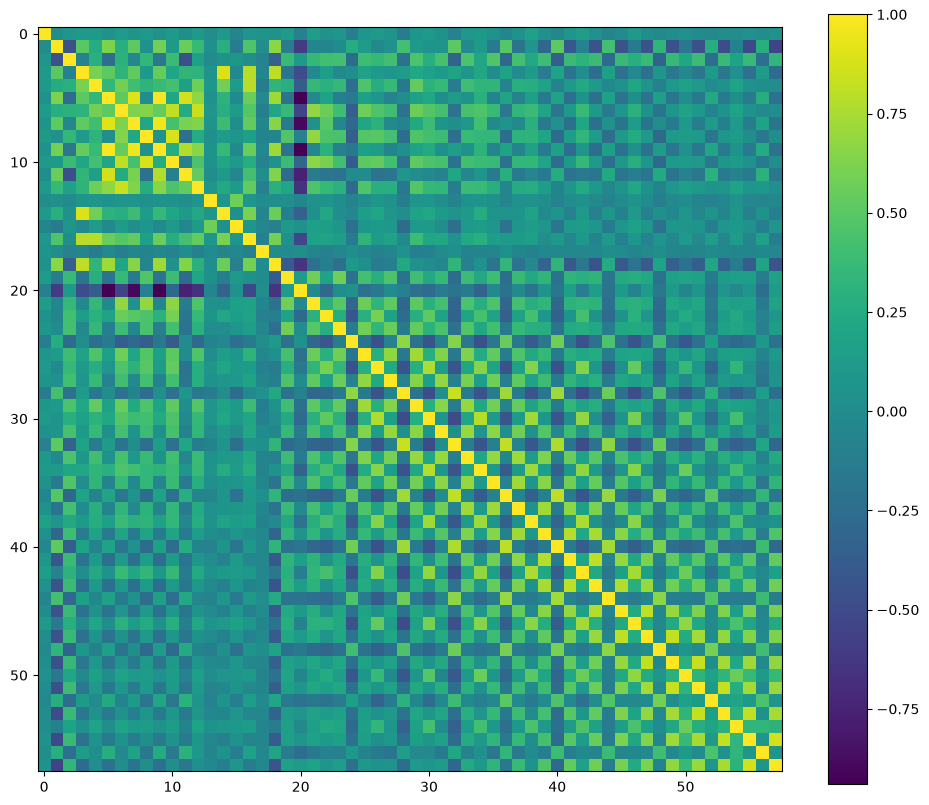

In [61]:
plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar()

plt.show()

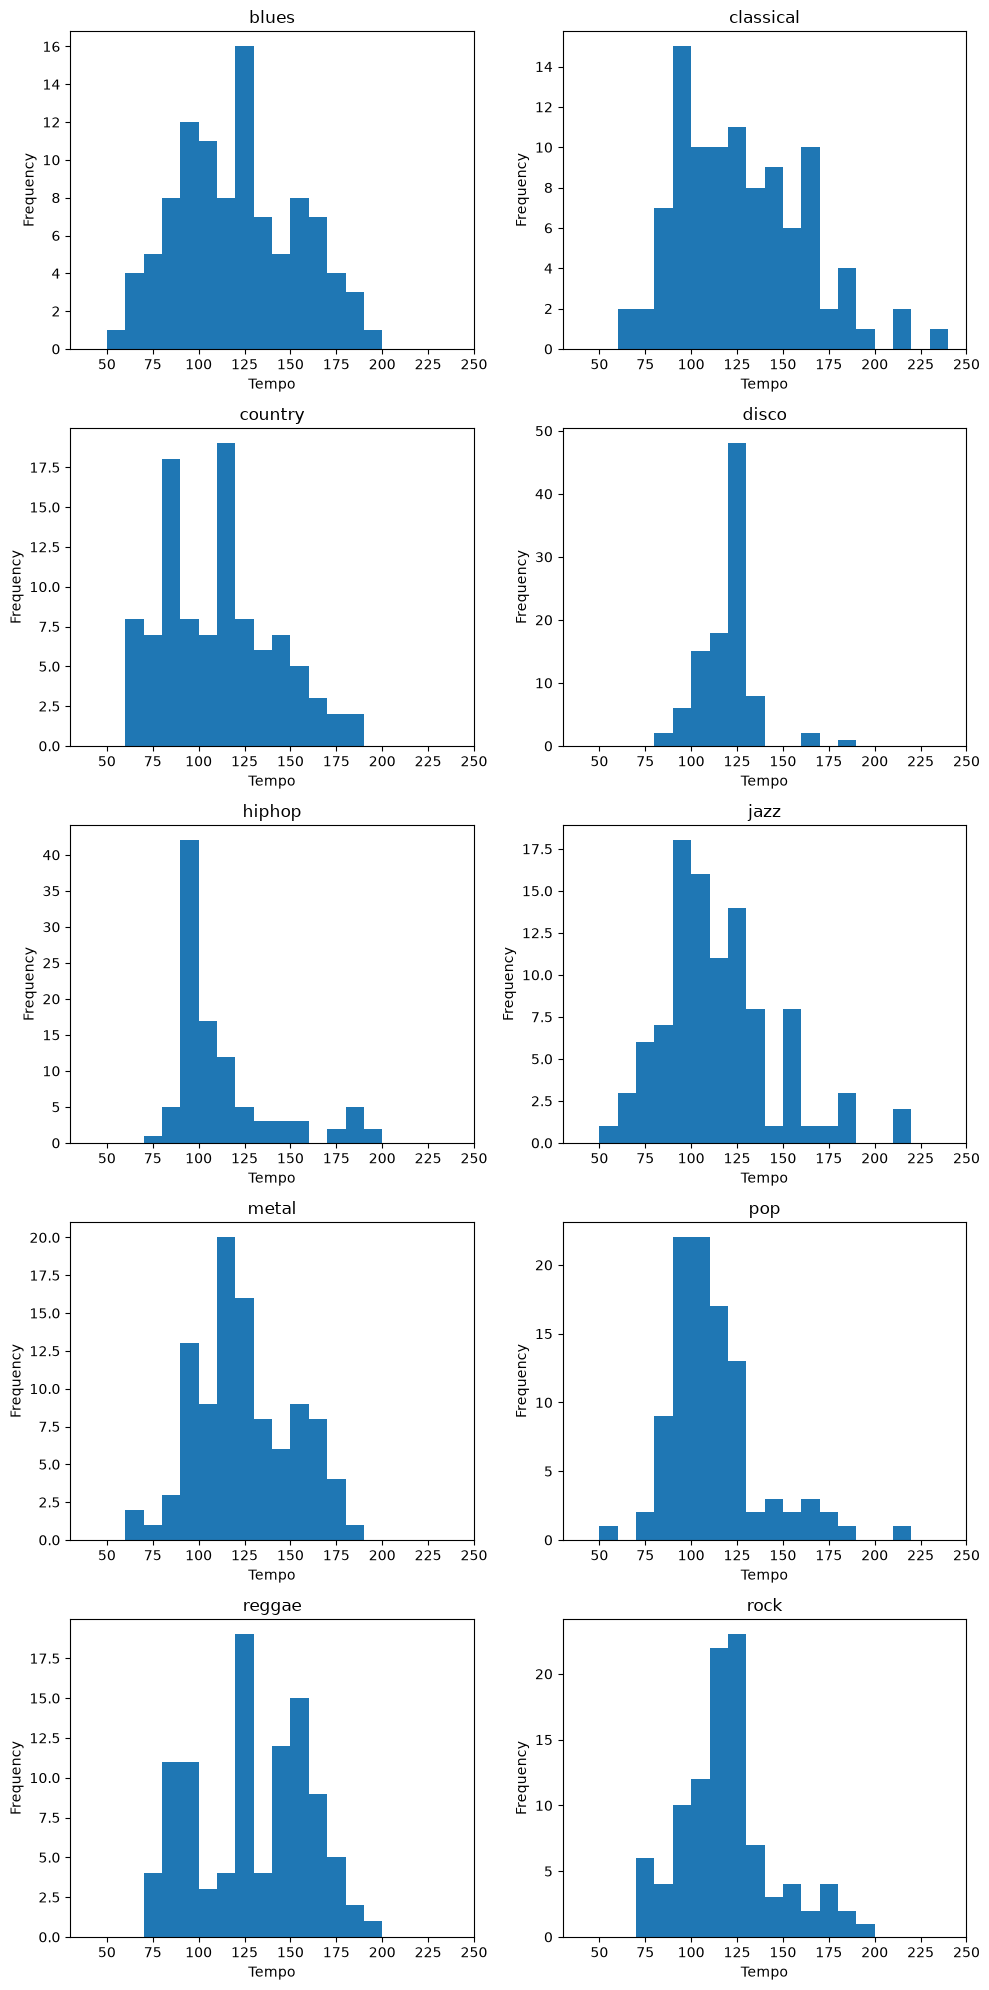

In [62]:
genres = df["label"].unique()

n = len(genres)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = axes.flatten()  # Makes indexing easier

for ax, genre in zip(axes, genres):
    subset = df[df["label"] == genre]

    ax.hist(subset["tempo"], bins=20, range=(40,240))
    ax.set_title(genre)
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Frequency")
    

plt.tight_layout()
plt.show()

## Configuración de dispositivo (CPU / GPU)

A partir de aquí comienza la parte de deep learning del proyecto (espectrogramas + CNN preentrenado), donde se usa PyTorch y, cuando está disponible, aceleración por GPU vía CUDA.

Como no todos los integrantes del equipo cuentan con GPU compatible con CUDA, el dispositivo de ejecución se detecta automáticamente al inicio del notebook, usando CPU cuando no hay GPU disponible. Con esto el mismo código corre sin modificaciones en ambas máquinas del equipo; la única diferencia es el tiempo de ejecución.


In [63]:
import torch
import sys

# Diagnóstico del entorno: útil para confirmar que la instalación de PyTorch reconoce
# (o no) la GPU de la máquina donde se ejecuta el notebook.
print("Torch:", torch.__version__)
print("CUDA de Torch:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
print("Python:", sys.executable)

# El dispositivo se detecta automáticamente según el hardware disponible en cada máquina.
# Esta decisión evita tener que mantener dos versiones del notebook (una para GPU y otra
# para CPU) y permite que ambos integrantes trabajen sobre el mismo código.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")

if device.type == "cuda":
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU compatible con CUDA; se utilizará CPU.")


Torch: 2.13.0+cu130
CUDA de Torch: 13.0
CUDA disponible: False
Número de GPUs: 0
Python: /home/thunderm/miniconda3/envs/inro-ia/bin/python
Dispositivo en uso: cpu
No se detectó GPU compatible con CUDA; se utilizará CPU.


## Conversión de audio a espectrogramas (feature engineering)

El dataset GTZAN descargado mediante `kagglehub` (celda "Descarga del dataset") se copia localmente a `./Data`, e incluye los audios `.wav` originales en `Data/genres_original/<genero>/`, además de los `.csv` con features ya calculadas que se usaron en el análisis exploratorio inicial.

Para el modelo de deep learning se trabaja directamente con los audios, convirtiéndolos en espectrogramas mel en escala logarítmica (dB): esta es la representación que finalmente procesa el CNN preentrenado, tratada como si fuera una imagen. La conversión se realiza íntegramente en CPU (librosa no requiere GPU), por lo que este paso toma un tiempo comparable en ambas máquinas del equipo; la GPU se utiliza recién en la etapa de entrenamiento.

Cada clip de 30 segundos se segmenta en ventanas de 3 segundos, lo que además de aumentar la cantidad de ejemplos disponibles para entrenar, funciona como una forma simple de ampliar el dataset.


In [64]:
import os
import glob
from pathlib import Path

import librosa
import librosa.display
from tqdm.auto import tqdm

# Carpeta con los audios .wav originales, dentro de lo descargado por kagglehub
AUDIO_DIR = Path(path) / "genres_original"

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]

# Conteo de archivos por género, a modo de verificación de que la descarga fue correcta
for genre in GENRES:
    n_files = len(glob.glob(str(AUDIO_DIR / genre / "*.wav")))
    print(f"{genre:10s}: {n_files} archivos")


blues     : 100 archivos
classical : 100 archivos
country   : 100 archivos
disco     : 100 archivos
hiphop    : 100 archivos
jazz      : 100 archivos
metal     : 100 archivos
pop       : 100 archivos
reggae    : 100 archivos
rock      : 100 archivos


In [65]:
SR = 22050              # sample rate al que se cargan los audios
N_MELS = 128             # bandas mel del espectrograma
SEGMENT_SECONDS = 3      # duración de cada sub-clip

def audio_to_melspec_segments(filepath, sr=SR, n_mels=N_MELS, segment_seconds=SEGMENT_SECONDS):
    """Carga un clip de audio, lo divide en segmentos de `segment_seconds` y devuelve
    una lista de espectrogramas log-mel (dB), uno por segmento."""
    y, _ = librosa.load(filepath, sr=sr)
    segment_len = sr * segment_seconds
    n_segments = len(y) // segment_len

    specs = []
    for i in range(n_segments):
        segment = y[i * segment_len:(i + 1) * segment_len]
        mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        specs.append(mel_db)
    return specs


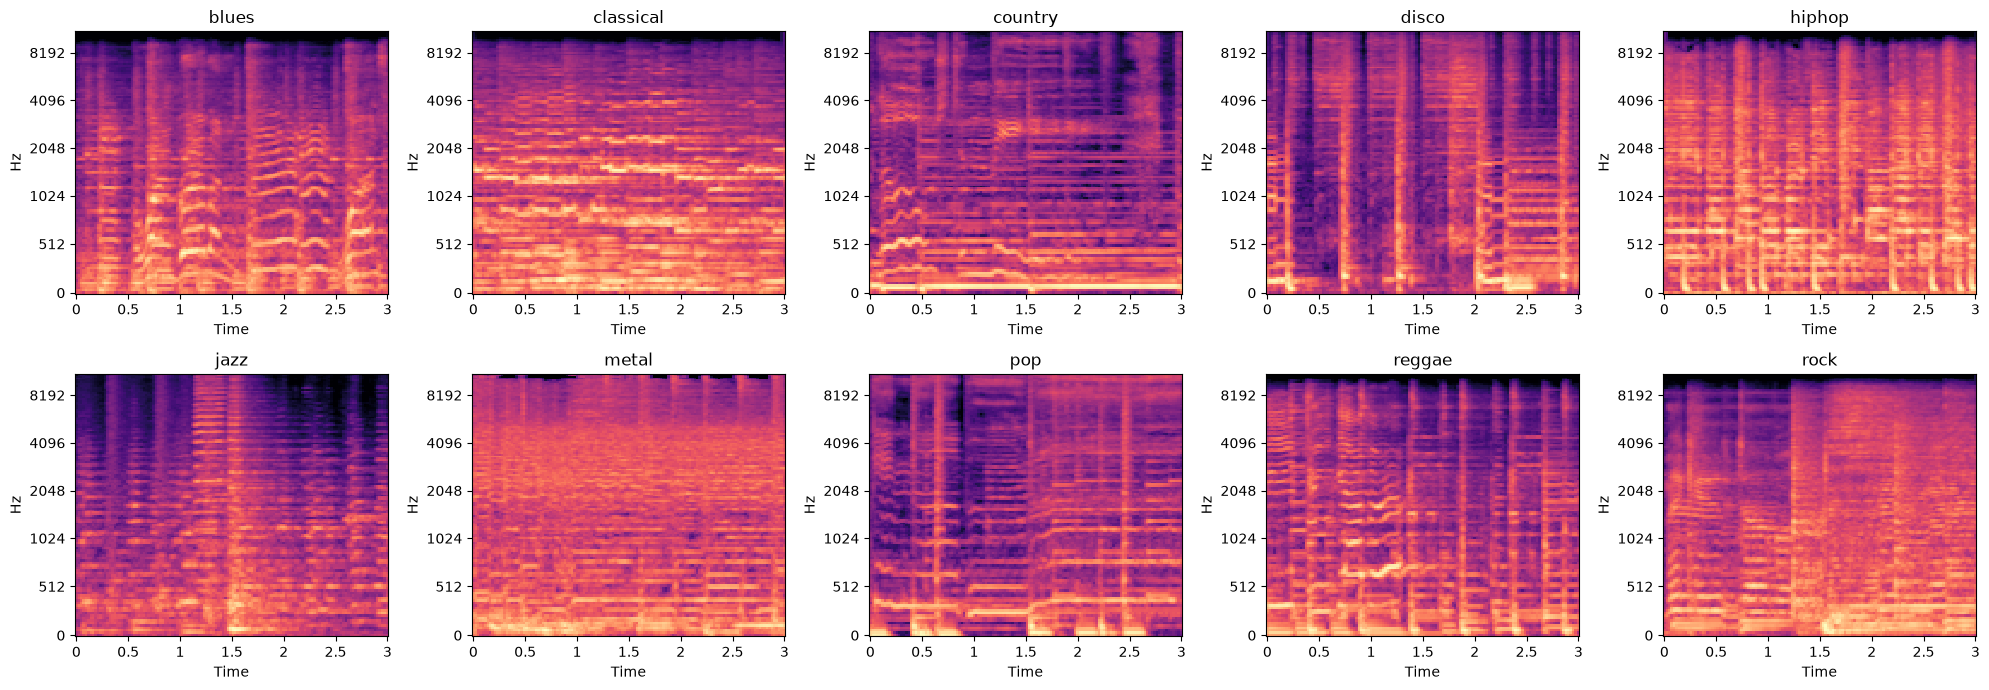

In [66]:
# Vista previa: un espectrograma de ejemplo por género, a modo de verificación visual
# de que la conversión produce resultados razonables antes de procesar todo el dataset.
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, genre in zip(axes.flat, GENRES):
    sample_files = sorted(glob.glob(str(AUDIO_DIR / genre / "*.wav")))
    if not sample_files:
        continue
    specs = audio_to_melspec_segments(sample_files[0])
    librosa.display.specshow(specs[0], sr=SR, x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(genre)
plt.tight_layout()
plt.show()


In [67]:
# Se generan y cachean todos los espectrogramas como archivos .npy en disco. Este paso
# se ejecuta una sola vez por máquina, ya que el resultado queda guardado localmente
# (la carpeta "spectrograms" se excluye del repositorio mediante .gitignore por su peso).
SPEC_DIR = Path("spectrograms")
SPEC_DIR.mkdir(exist_ok=True)

records = []
audio_files = []
for genre in GENRES:
    for f in sorted(glob.glob(str(AUDIO_DIR / genre / "*.wav"))):
        audio_files.append((f, genre))

for filepath, genre in tqdm(audio_files, desc="Generando espectrogramas"):
    song_id = Path(filepath).stem
    try:
        specs = audio_to_melspec_segments(filepath)
    except Exception as e:
        # Algunos .wav de GTZAN presentan errores de lectura, un problema conocido del
        # dataset; en esos casos se omite el archivo y se deja registro en la salida.
        print(f"Se omite {filepath}: {e}")
        continue

    for j, spec in enumerate(specs):
        out_path = SPEC_DIR / f"{genre}_{song_id}_{j}.npy"
        np.save(out_path, spec)
        records.append({"spec_path": str(out_path), "genre": genre, "song_id": song_id})

spec_df = pd.DataFrame(records)
print(f"Total de segmentos (espectrogramas) generados: {len(spec_df)}")
spec_df.head()


Generando espectrogramas:  55%|█████▌    | 553/1000 [00:44<00:29, 15.02it/s]/tmp/ipykernel_8452/2403895253.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr)
/home/thunderm/miniconda3/envs/inro-ia/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Generando espectrogramas:  56%|█████▌    | 557/1000 [00:44<00:31, 14.19it/s]

Se omite /home/thunderm/intro-ia/proyecto-2-intro-IA/Data/genres_original/jazz/jazz.00054.wav: 


Generando espectrogramas: 100%|██████████| 1000/1000 [01:25<00:00, 11.74it/s]

Total de segmentos (espectrogramas) generados: 9981


,spec_path,genre,song_id
0,spectrograms/blues_blues.00000_0.npy,blues,blues.00000
1,spectrograms/blues_blues.00000_1.npy,blues,blues.00000
2,spectrograms/blues_blues.00000_2.npy,blues,blues.00000
3,spectrograms/blues_blues.00000_3.npy,blues,blues.00000
4,spectrograms/blues_blues.00000_4.npy,blues,blues.00000


In [68]:
# División train/val/test, estratificada por género y agrupada por canción original,
# para evitar que segmentos de una misma canción queden repartidos entre conjuntos
# distintos (lo que constituiría una fuga de información entre train y test).
from sklearn.model_selection import train_test_split


import torch
print(torch.__file__)

song_ids = spec_df[["song_id", "genre"]].drop_duplicates()
train_songs, test_songs = train_test_split(
    song_ids, test_size=0.2, stratify=song_ids["genre"], random_state=42
)
train_songs, val_songs = train_test_split(
    train_songs, test_size=0.15, stratify=train_songs["genre"], random_state=42
)

train_df = spec_df[spec_df.song_id.isin(train_songs.song_id)].reset_index(drop=True)
val_df = spec_df[spec_df.song_id.isin(val_songs.song_id)].reset_index(drop=True)
test_df = spec_df[spec_df.song_id.isin(test_songs.song_id)].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


/home/thunderm/miniconda3/envs/inro-ia/lib/python3.11/site-packages/torch/__init__.py
Train: 6782 | Val: 1199 | Test: 2000


## Dataset, DataLoader y modelo

A partir de esta sección el código utiliza efectivamente la GPU cuando está disponible: los tensores y el modelo se envían al dispositivo definido en `device`. Como esa variable se calculó automáticamente al inicio del notebook, esta parte se ejecuta sin cambios tanto en la máquina con GPU como en la que no la tiene.


In [69]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def spec_to_tensor(spec):
    """Normaliza un espectrograma a [0,1], lo replica a 3 canales y lo redimensiona a
    224x224. El tensor resultante queda en CPU; el traspaso a `device` se hace recién
    dentro del loop de entrenamiento."""
    spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
    tensor = tensor.repeat(3, 1, 1)
    tensor = torch.nn.functional.interpolate(
        tensor.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False
    ).squeeze(0)
    return tensor


def spec_augment(spec, freq_mask_param=15, time_mask_param=25, n_masks=2):
    """SpecAugment (Park et al., 2019): enmascara bandas de frecuencia y tramos de
    tiempo al azar sobre el espectrograma, como estrategia de data augmentation para
    audio, equivalente en espíritu a rotar/recortar imágenes en visión.

    Implementación pendiente a cargo de Martín. La función ya está integrada en el
    pipeline (el Dataset la invoca cuando augment=True), por lo que una vez completada
    no se requiere modificar nada más para que el augmentation quede activo durante el
    entrenamiento.

    Lógica a implementar:
        - Trabajar sobre una copia del espectrograma, para no alterar el original.
        - Elegir al azar un ancho y una posición de banda de frecuencia (acotados por
          freq_mask_param) y fijar esa franja en el valor mínimo del espectrograma.
        - Repetir el mismo procedimiento en el eje temporal, acotado por time_mask_param.
        - Aplicar ambos enmascaramientos n_masks veces.
    """

    # Hecho.
    augmented = spec.copy()

    n_freq, n_time = augmented.shape
    mask_value = augmented.min()

    for _ in range(n_masks):
        # Máscara de frecuencia
        f = np.random.randint(0, min(freq_mask_param, n_freq) + 1)
        if f > 0:
            f0 = np.random.randint(0, n_freq - f + 1)
            augmented[f0:f0 + f, :] = mask_value

        # Máscara temporal
        t = np.random.randint(0, min(time_mask_param, n_time) + 1)
        if t > 0:
            t0 = np.random.randint(0, n_time - t + 1)
            augmented[:, t0:t0 + t] = mask_value

    return augmented


class SpectrogramDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(row.spec_path)
        if self.augment:
            spec = spec_augment(spec)
        tensor = spec_to_tensor(spec)
        tensor = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(tensor)
        label = GENRE_TO_IDX[row.genre]
        return tensor, label


BATCH_SIZE = 32

train_ds = SpectrogramDataset(train_df, augment=True)
val_ds = SpectrogramDataset(val_df, augment=False)
test_ds = SpectrogramDataset(test_df, augment=False)

# num_workers=0 por compatibilidad entre sistemas operativos distintos dentro del equipo
# (evita problemas conocidos en Windows/Mac); puede subirse a 2-4 si el entorno lo permite.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches -> train: 212, val: 38, test: 63


In [70]:
def build_model(num_classes=10, freeze_backbone=True, dropout=0.4):
    """Construye el modelo por transfer learning: ResNet18 preentrenado en ImageNet,
    con la cabeza de clasificación reemplazada para las 10 clases del problema. El
    dropout en la cabeza es la primera de las estrategias de regularización aplicadas."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

model = build_model()
print(model.fc)


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


In [71]:
class EarlyStopping:
    """Detiene el entrenamiento si val_loss deja de mejorar durante `patience` épocas
    consecutivas.

    Implementación pendiente, a cargo de Martín. La clase ya está instanciada y se
    invoca en cada época dentro de train_model(); mientras el método step() no compare
    las pérdidas entre sí, should_stop permanece en False y el entrenamiento no se
    corta anticipadamente.

    Lógica a implementar en step(val_loss):
        - Si val_loss mejora respecto a best_loss en más de min_delta, actualizar
          best_loss y reiniciar el contador en 0.
        - Si no mejora, incrementar el contador; al alcanzar patience, activar
          should_stop = True.
    """
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        # Hecho el step. 
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            # Los batches se envían a `device`: será GPU si hay CUDA disponible, o CPU si no.
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs, lr, weight_decay, patience=5):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    # weight_decay corresponde a la regularización L2, ya aplicada acá.
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} acc={train_acc:.3f} "
              f"| val_loss={val_loss:.4f} acc={val_acc:.3f}")

        early_stopping.step(val_loss)  # sin efecto hasta que se implemente EarlyStopping.step()
        if early_stopping.should_stop:
            print("Early stopping activado.")
            break

    return history


In [72]:
# Fase 1: solo se entrena la cabeza (backbone congelado)
model = build_model(freeze_backbone=True)
history_phase1 = train_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=1e-4)
print("Fase 1 completada.")

Epoch 1/15 | train_loss=2.0622 acc=0.288 | val_loss=1.8104 acc=0.434
Epoch 2/15 | train_loss=1.8322 acc=0.392 | val_loss=1.6464 acc=0.519
Epoch 3/15 | train_loss=1.8013 acc=0.410 | val_loss=1.6096 acc=0.517
Epoch 4/15 | train_loss=1.7761 acc=0.411 | val_loss=1.5888 acc=0.561
Epoch 5/15 | train_loss=1.7669 acc=0.431 | val_loss=1.5669 acc=0.561
Epoch 6/15 | train_loss=1.7669 acc=0.429 | val_loss=1.5821 acc=0.550
Epoch 7/15 | train_loss=1.7647 acc=0.427 | val_loss=1.5483 acc=0.581
Epoch 8/15 | train_loss=1.7576 acc=0.433 | val_loss=1.5920 acc=0.517
Epoch 9/15 | train_loss=1.7629 acc=0.431 | val_loss=1.5843 acc=0.540
Epoch 10/15 | train_loss=1.7771 acc=0.422 | val_loss=1.5971 acc=0.525
Epoch 11/15 | train_loss=1.7356 acc=0.440 | val_loss=1.5274 acc=0.576
Epoch 12/15 | train_loss=1.7256 acc=0.446 | val_loss=1.5195 acc=0.589
Epoch 13/15 | train_loss=1.7198 acc=0.453 | val_loss=1.5273 acc=0.595
Epoch 14/15 | train_loss=1.7318 acc=0.450 | val_loss=1.5502 acc=0.547
Epoch 15/15 | train_loss=1.71

In [81]:
# Fase 2: fine-tuning -> se descongela el último bloque residual, con LR reducido
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

history_phase2 = train_model(model, train_loader, val_loader, epochs=10, lr=1e-5, weight_decay=1e-4)
print("Fase 2 completada.")

Epoch 1/10 | train_loss=1.6551 acc=0.480 | val_loss=1.3695 acc=0.650
Epoch 2/10 | train_loss=1.5661 acc=0.526 | val_loss=1.3080 acc=0.672
Epoch 3/10 | train_loss=1.5090 acc=0.562 | val_loss=1.2573 acc=0.695
Epoch 4/10 | train_loss=1.4655 acc=0.581 | val_loss=1.2392 acc=0.697
Epoch 5/10 | train_loss=1.4144 acc=0.604 | val_loss=1.1966 acc=0.706
Epoch 6/10 | train_loss=1.4006 acc=0.613 | val_loss=1.1667 acc=0.734
Epoch 7/10 | train_loss=1.3678 acc=0.634 | val_loss=1.1564 acc=0.746
Epoch 8/10 | train_loss=1.3305 acc=0.644 | val_loss=1.1484 acc=0.744
Epoch 9/10 | train_loss=1.3102 acc=0.665 | val_loss=1.1212 acc=0.759
Epoch 10/10 | train_loss=1.3010 acc=0.664 | val_loss=1.1029 acc=0.772
Fase 2 completada.


**Nota sobre tiempos de ejecución.** En CPU, cada época de la Fase 1 puede tomar considerablemente más tiempo que en GPU. Si el entrenamiento resulta muy lento en la máquina sin GPU, se puede reducir `epochs` o `BATCH_SIZE`, o correr únicamente la Fase 1 como verificación de que el pipeline funciona, dejando la corrida completa (Fase 1 + Fase 2) para la máquina con GPU. El código es idéntico en ambos casos, solo cambia el tiempo de ejecución.

**Estado de las estrategias de regularización implementadas:**
- Dropout en la cabeza del clasificador (`build_model`): implementado.
- Weight decay / L2 en el optimizer (`train_model`): implementado.
- SpecAugment (`spec_augment`): pendiente, ver definición más arriba.
- Early stopping (`EarlyStopping.step`): pendiente, ver definición más arriba.


## Curvas de entrenamiento

Corresponde graficar loss y accuracy de train/val a lo largo de ambas fases de entrenamiento, para evaluar si existió sobreajuste (separación creciente entre las curvas de train y val) y si el fine-tuning de la Fase 2 aportó una mejora medible respecto a la Fase 1.


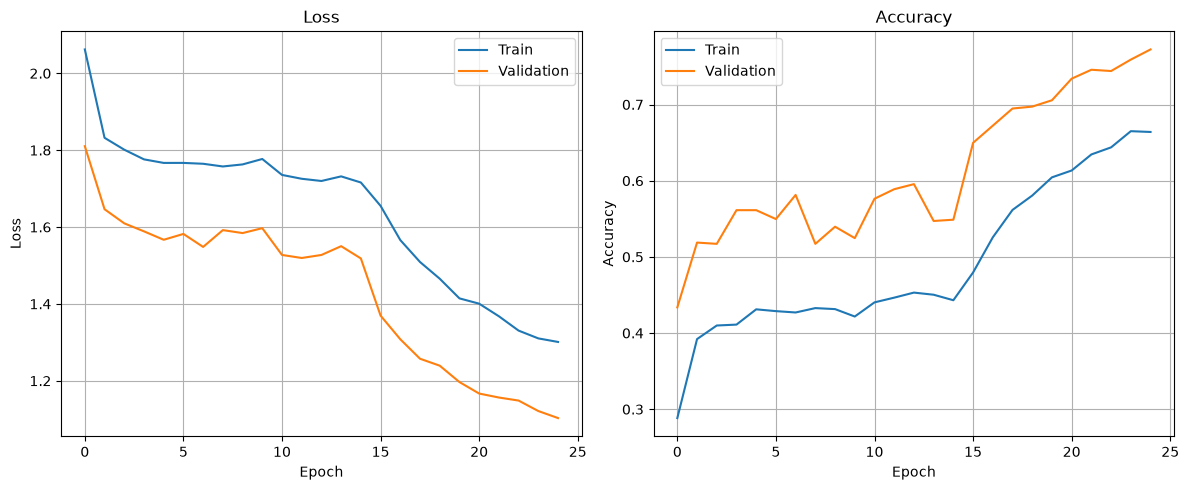

In [84]:
def plot_history(*histories):
    """Grafica loss y accuracy de entrenamiento y validación a partir de uno o más
    diccionarios `history` (los que retorna train_model), concatenando las fases en orden.

    Implementación pendiente. Pasos a seguir:
        - Concatenar las listas de cada history (train_loss, val_loss, train_acc, val_acc)
          en el orden en que se entregan los histories.
        - Crear una figura con dos subplots.
        - En el primero, graficar train_loss y val_loss con su leyenda y título "Loss".
        - En el segundo, graficar train_acc y val_acc con su leyenda y título "Accuracy".
    """
    # Hecho
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    # Concatenar historiales
    for history in histories:
        train_loss.extend(history["train_loss"])
        val_loss.extend(history["val_loss"])
        train_acc.extend(history["train_acc"])
        val_acc.extend(history["val_acc"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss
    axes[0].plot(train_loss, label="Train")
    axes[0].plot(val_loss, label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(train_acc, label="Train")
    axes[1].plot(val_acc, label="Validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


plot_history(history_phase1,history_phase2)


## Testeo y métricas

Corresponde evaluar el modelo sobre el conjunto de test (canciones no vistas durante entrenamiento ni validación), reportando accuracy, F1 por clase (macro, dado que el dataset está balanceado entre géneros) y matriz de confusión.


In [85]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, loader):
    """Ejecuta el modelo sobre un DataLoader sin calcular gradientes y devuelve dos
    arreglos numpy: las etiquetas reales y las predichas.

    Implementación pendiente. Pasos a seguir:
        - Poner el modelo en modo evaluación (model.eval()).
        - Recorrer el loader dentro de torch.no_grad(), enviando los batches a device.
        - Acumular las predicciones (argmax de la salida del modelo) y las etiquetas reales.
        - Retornar ambos arreglos como np.array.
    """
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = outputs.argmax(dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


y_true, y_pred = evaluate(model, test_loader)
print(classification_report(y_true, y_pred, target_names=GENRES))


              precision    recall  f1-score   support

       blues       0.78      0.73      0.75       200
   classical       0.89      0.95      0.92       200
     country       0.58      0.81      0.68       200
       disco       0.66      0.59      0.62       200
      hiphop       0.77      0.79      0.78       200
        jazz       0.77      0.90      0.83       200
       metal       0.88      0.83      0.86       200
         pop       0.64      0.79      0.71       200
      reggae       0.77      0.58      0.66       200
        rock       0.61      0.36      0.45       200

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000



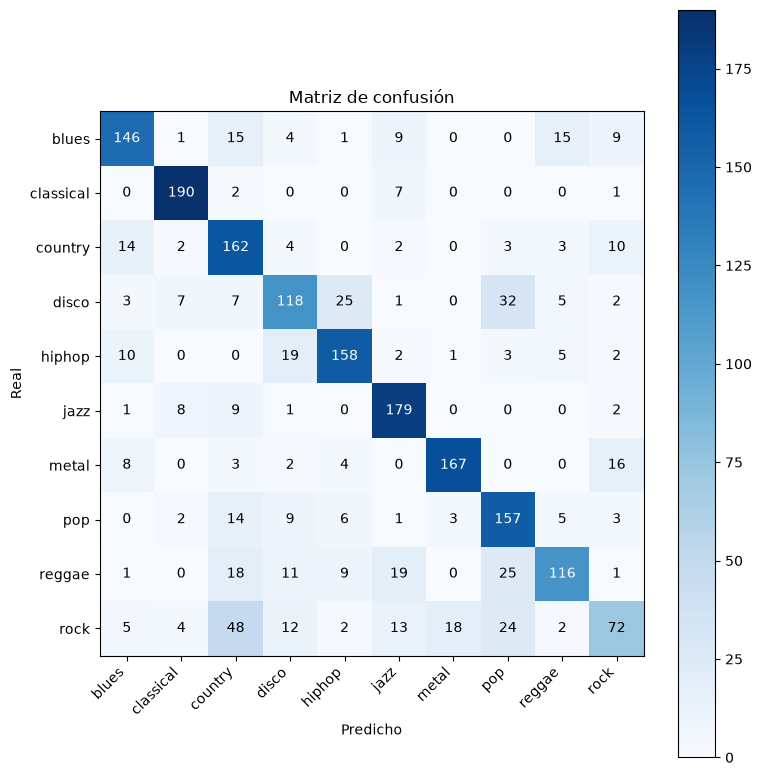

In [86]:
# Matriz de confusión sobre el conjunto de test. Pendiente de implementación.
#
# Pasos a seguir:
#   - Calcular la matriz con confusion_matrix(y_true, y_pred).
#   - Graficarla (por ejemplo con plt.imshow), usando GENRES como etiquetas de los ejes.
#   - Anotar cada celda con su valor numérico para facilitar la lectura.
#   - Etiquetar los ejes como "Predicho" y "Real".

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Graficar
plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(np.arange(len(GENRES)), GENRES, rotation=45, ha="right")
plt.yticks(np.arange(len(GENRES)), GENRES)

# Anotar cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


## Ejemplos mal clasificados

Corresponde inspeccionar visualmente algunos espectrogramas donde el modelo se equivocó, como insumo para la discusión en las conclusiones sobre qué géneros se confunden entre sí y por qué (por ejemplo, rock y metal, o jazz y blues, comparten rasgos espectrales).


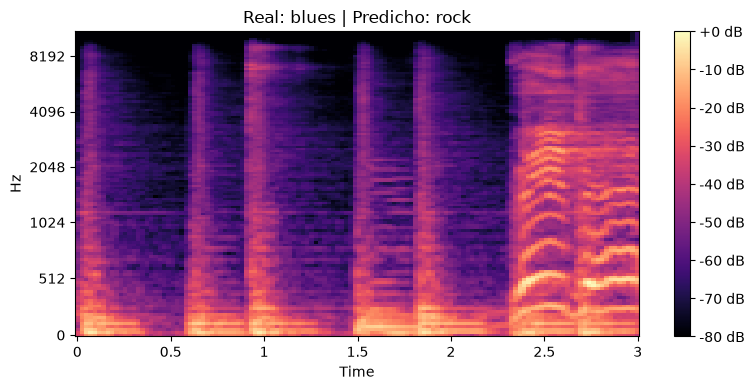

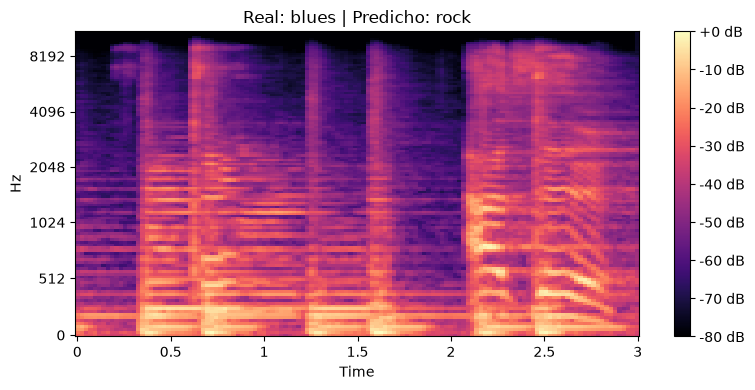

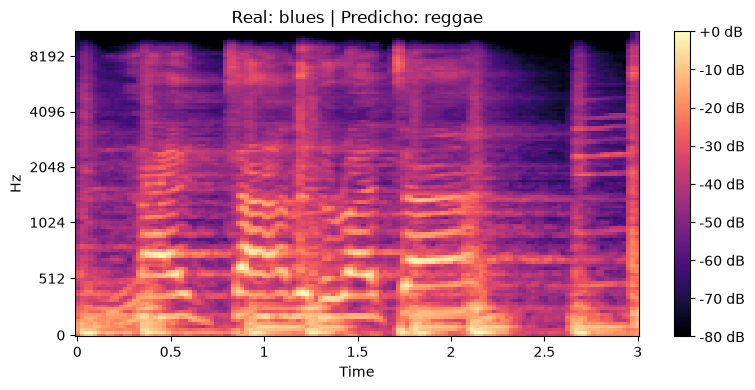

In [87]:
# Visualización de espectrogramas mal clasificados. Pendiente de implementación.
#
# Pasos a seguir:
#   - Identificar los índices donde y_true != y_pred.
#   - Para cada uno, cargar el espectrograma correspondiente (test_df.iloc[idx].spec_path)
#     y graficarlo con librosa.display.specshow.
#   - Indicar en el título de cada gráfico el género real y el predicho.



# Índices de ejemplos mal clasificados
misclassified = np.where(y_true != y_pred)[0]
maximum_displayed = 3
count = 0
for idx in misclassified:
    if count >= maximum_displayed:
        break
    # Cargar espectrograma
    spec = np.load(test_df.iloc[idx].spec_path)

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(
        spec,
        x_axis="time",
        y_axis="mel",
        cmap="magma"
    )
    plt.colorbar(format="%+2.0f dB")

    plt.title(
        f"Real: {GENRES[y_true[idx]]} | Predicho: {GENRES[y_pred[idx]]}"
    )

    plt.tight_layout()
    plt.show()
    count += 1

## Conclusiones

El modelo alcanzó una **accuracy de 55%** y un **F1-score de 0.54** sobre el conjunto de prueba, superando el **baseline aleatorio de 10%** esperado para un problema de clasificación balanceado con diez géneros musicales, usando el entrenamiento solo hasta la fase 1. Estos resultados indican que la red fue capaz de aprender representaciones útiles de los espectrogramas, aunque todavía existe un margen importante de mejora para diferenciar géneros con características acústicas similares, que se esperan alcanzar al ejecutar la segunda fase de entrenamiento (Que yo, Martín, no puedo realizar porque mi PC no tiene GPU dedicada).

La matriz de confusión muestra que el desempeño varía considerablemente entre clases. Los mejores resultados se obtuvieron para **classical** (185 aciertos de 200) y **metal** (153 de 200), mientras que **reggae** (33 de 200) y **rock** (67 de 200) fueron las clases con menor tasa de aciertos. Entre las confusiones más frecuentes destacan **reggae → pop** (58 casos), **country → blues** (56), **hiphop → blues** (55), **jazz → blues** (50), **rock → metal** (44) y **disco → pop** (57). Estas confusiones son razonables desde el punto de vista musical, ya que varios de estos géneros comparten patrones rítmicos, instrumentación, tempo o características de sonido similares. En particular, el modelo muestra una tendencia a sobrepredecir la clase *blues*, lo que explica su alto recall (0.83) pero baja precisión (0.36).

La incorporación de **SpecAugment** probablemente contribuyó a este comportamiento al exponer al modelo a versiones parcialmente enmascaradas de los espectrogramas durante el entrenamiento, incrementando la variabilidad de los datos y reduciendo la dependencia de características específicas. Asimismo, el uso de **early stopping** evitó continuar el entrenamiento una vez que el desempeño sobre el conjunto de validación dejó de mejorar, reduciendo el riesgo de sobreajuste y evitando entrenar durante más épocas de las necesarias.

Una vez ejecutada la fase 2 del entrenamiento del modelo, se alcanzó un **accuracy del 73%** y un **F1-score de 0.73**, Que es un salto significativo sobre el entrenamiento inicial que incluía solo hasta la fase 1 del entrenamiento.

Finalmente, el enfoque presenta varias limitaciones. En primer lugar, **GTZAN** es un conjunto de datos relativamente pequeño para entrenar modelos profundos, por lo que la capacidad de generalización es limitada. Además, trabajar con segmentos de **3 segundos** implica perder parte del contexto musical de largo plazo, como la estructura completa de una canción o la evolución temporal de sus patrones rítmicos y armónicos. 

Además, buscando referencias acerca del dataset encontramos que hay documentos que dicen de la existencia de duplicados y datos imprecisos en GTZAN, lo que introduce una fuente adicional de error tanto durante el entrenamiento como en la evaluación del modelo.

Referencia: Sturm, B. L. (2013). The GTZAN dataset: Its contents, its faults, their effects on evaluation, and its future use. arXiv:1306.1461.